In [53]:
import numpy as np
import matplotlib.pyplot as plt

def projection_simplex_sort(v, z=1):
    n_features = v.shape[0]
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - z
    ind = np.arange(n_features) + 1
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / float(rho)
    w = np.maximum(v - theta, 0)

    return w

def duality_gap(A, x, y):

    return max(A.T @ x) - min(A @ y)

def energy(x, y, x_star, y_star, A, eta1, eta2):

    return sum((x - x_star) ** 2) / eta1 + sum((y - y_star) ** 2) / eta2 - sum((A @ (y - y_star)) * (x - x_star))

In [54]:
np.random.seed(42)
n, m = 50, 60
A = np.random.rand(n, m)

T = int(1e7)

x0 = np.ones(n) / n
y0 = np.ones(m) / m

eta = 0.01

print(A.shape)

(50, 60)


In [55]:
from tqdm import tqdm

x, y = x0, y0
avg_x, avg_y = x, y
altGDA_duality_gap = []

for k in tqdm(range(T)):
    x = projection_simplex_sort(x - eta * A @ y)
    y = projection_simplex_sort(y + eta * A.T @ x)  # Alternating

    avg_x = avg_x + (x - avg_x) / (k + 1)
    avg_y = avg_y + (y - avg_y) / (k + 1)

    altGDA_duality_gap.append(duality_gap(A, avg_x, avg_y))

In [ ]:
from tqdm import tqdm

x, y = x0, y0
avg_x, avg_y = x, y
simGDA_duality_gap = []

for k in tqdm(range(T)):
    x_, y_ = x, y
    x = projection_simplex_sort(x - eta * A @ y_)
    y = projection_simplex_sort(y + eta * A.T @ x_)  # Simultaneous

    avg_x = avg_x + (x - avg_x) / (k + 1)
    avg_y = avg_y + (y - avg_y) / (k + 1)

    simGDA_duality_gap.append(duality_gap(A, avg_x, avg_y))

100%|██████████| 10000000/10000000 [09:07<00:00, 18272.55it/s]


C:\Users\Tianlong Nan\AppData\Local\Temp\ipykernel_64848\1757458769.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels, rotation=90)


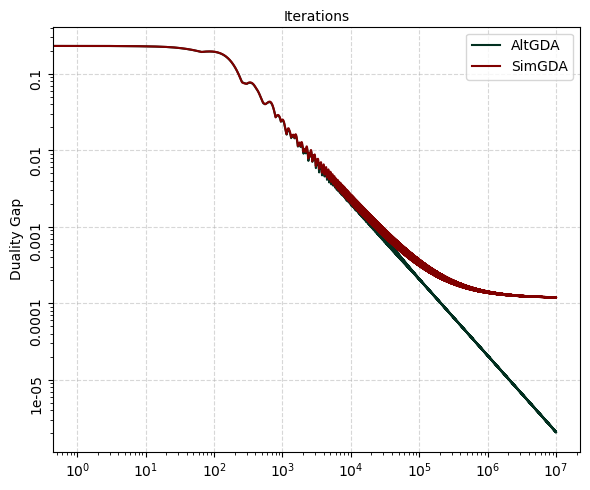

In [ ]:
# duality gap

ax = plt.figure(figsize=(6, 5)).gca()

ax.loglog(list(range(T)), altGDA_duality_gap, c='#023020', label='AltGDA')
ax.loglog(list(range(T)), simGDA_duality_gap, c='#800000', label='SimGDA')
ax.set_xlabel('Iterations')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Duality Gap')
y_labels = ax.get_yticks().tolist()
ax.set_yticklabels(y_labels, rotation=90)
ax.grid(True, ls="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

# Save the plot
ax.figure.savefig(f'AltGDA_vs_SimGDA_{n}_{m}_{T}.png', dpi=300)